In [18]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

from glob import glob
from collections import Counter

In [2]:
data_path = "data/raw/*.csv"
files = glob(data_path)
dfs = []

for file in files:
  df = pd.read_csv(file)
  
  # ambil nama file jadi nama bank
  bank_name = os.path.basename(file).replace(".csv", "")
  df["bank"] = bank_name
  
  dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print("Total data:", df.shape)
df.head()

Total data: (672627, 12)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank
0,e17751da-bf2e-4a8f-a5a8-334206bb93ca,pajar,https://play-lh.googleusercontent.com/a/ACg8oc...,ribet banget ni apk sumpah dikir' verif dikit'...,1,0,NaN,2025-12-31 23:57:59,Mohon maaf atas ketidaknyamanan Bapak/Ibu. Moh...,2026-01-01 00:10:13,NaN,BCAMobile_reviews
1,3481f1d1-a22f-445f-ae2f-ed8c2c9dca53,Jessica Slycia,https://play-lh.googleusercontent.com/a/ACg8oc...,kenapa QRis ga bisa di pakai ya?? daritadi loa...,2,0,4.7.7,2025-12-31 23:22:32,Mohon maaf atas ketidaknyamanan Bapak/Ibu. Moh...,2025-12-31 23:33:06,4.7.7,BCAMobile_reviews
2,af69ec6d-cc97-404e-b86a-e5f5b5f1f711,Bidibetico 09,https://play-lh.googleusercontent.com/a-/ALV-U...,"aplikasi nya sampah, kenapa tiba-tiba keluar t...",1,0,4.7.7,2025-12-31 23:06:58,Mohon maaf atas ketidaknyamanan Bapak/Ibu. Moh...,2025-12-31 23:30:30,4.7.7,BCAMobile_reviews
3,69174b3d-1234-4077-ac5a-d60aa10161e2,Pusat Data Win,https://play-lh.googleusercontent.com/a-/ALV-U...,sudah bagus dan lancar,5,0,4.7.7,2025-12-31 23:05:27,Terima kasih atas ulasannya. Semoga aplikasi B...,2025-12-31 23:32:05,4.7.7,BCAMobile_reviews
4,7181692a-d770-40aa-89bb-7cee4a772ad7,ade yanto,https://play-lh.googleusercontent.com/a-/ALV-U...,Sangat membantu,5,0,2.9.6,2025-12-31 22:24:00,Terima kasih atas ulasannya. Semoga aplikasi B...,2025-12-31 23:31:26,2.9.6,BCAMobile_reviews


In [3]:
df = df[["content", "score", "bank"]]

print(df.shape)
df.head()

(672627, 3)


,content,score,bank
0,ribet banget ni apk sumpah dikir' verif dikit'...,1,BCAMobile_reviews
1,kenapa QRis ga bisa di pakai ya?? daritadi loa...,2,BCAMobile_reviews
2,"aplikasi nya sampah, kenapa tiba-tiba keluar t...",1,BCAMobile_reviews
3,sudah bagus dan lancar,5,BCAMobile_reviews
4,Sangat membantu,5,BCAMobile_reviews


In [4]:
# drop duplicate
df = df.drop_duplicates(subset=["content"])

print("After cleaning:", df.shape)

After cleaning: (418251, 3)


# Basic EDA

In [5]:
df.isnull().sum()

content    0
score      0
bank       0
dtype: int64

In [6]:
print("Distribusi Rating:")
print(df["score"].value_counts().sort_index())

Distribusi Rating:
score
1    126817
2     29614
3     28736
4     26577
5    206507
Name: count, dtype: int64


In [7]:
print("Distribusi per Bank:")
result = df.groupby(["bank", "score"]).size().reset_index(name="count")
result = result.sort_values(by=["bank", "score"])

for bank in result["bank"].unique():
  bank_data = result[result["bank"] == bank]
  for idx, (_, row) in enumerate(bank_data.iterrows()):
    if idx == 0:
      print(f"{row['bank']:<25} {row['score']:<10} {row['count']}")
    else:
      print(f"{'':<25} {row['score']:<10} {row['count']}")

Distribusi per Bank:
BCAMobile_reviews         1          26807
                          2          5157
                          3          5039
                          4          3178
                          5          18373
BRImo_reviews             1          46225
                          2          10878
                          3          11331
                          4          14643
                          5          136463
Wondr_BNI_reviews         1          13320
                          2          3215
                          3          3321
                          4          2589
                          5          21903
livin_mandiri_reviews     1          40465
                          2          10364
                          3          9045
                          4          6167
                          5          29768


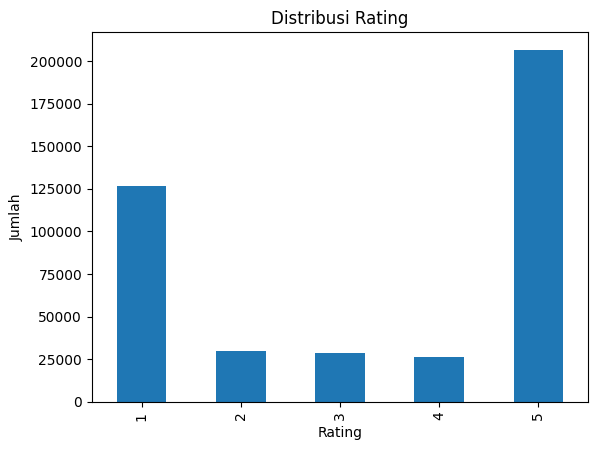

In [8]:
df["score"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah")
plt.show()

<Figure size 1200x600 with 0 Axes>

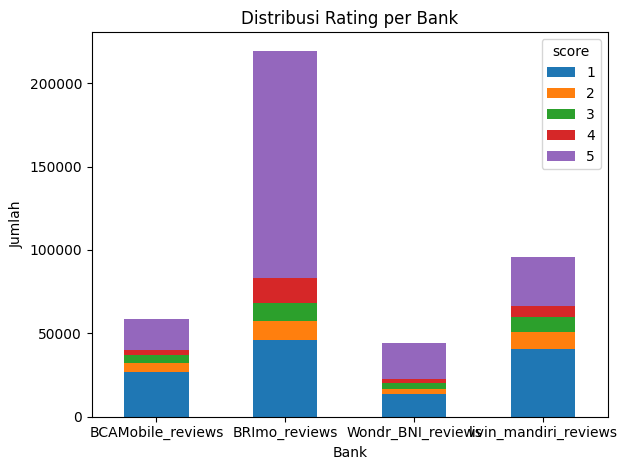

In [12]:
plt.figure(figsize=(12, 6))
df.groupby("bank")["score"].value_counts().unstack().plot(kind="bar", stacked=True)

plt.title("Distribusi Rating per Bank")
plt.xlabel("Bank")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

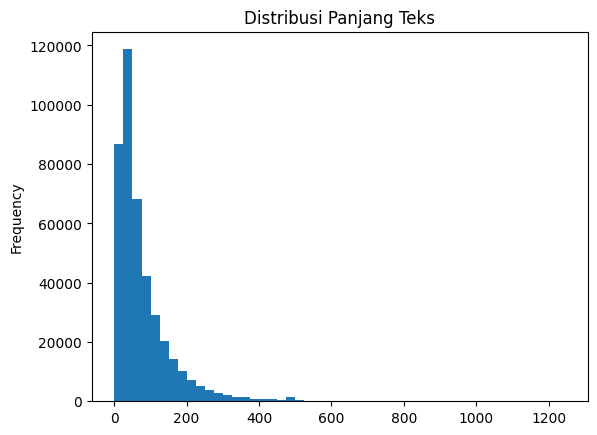

In [13]:
df["text_length"] = df["content"].astype(str).apply(len)

df["text_length"].plot(kind="hist", bins=50)
plt.title("Distribusi Panjang Teks")
plt.show()

# Filtering

In [14]:
df = df[df["score"].isin([1, 2, 3])]

print("After filter:", df.shape)
print(df["score"].value_counts())

After filter: (185167, 4)
score
1    126817
2     29614
3     28736
Name: count, dtype: int64


In [16]:
# sampling from each bank (3k sample)
def stratified_sample(group, n=3000):
  return group.groupby("score", group_keys=False).apply(lambda x: x.sample(min(len(x), int(n/3)), random_state=42))

df_sampled = df.groupby("bank", group_keys=False).apply(stratified_sample)

print(df_sampled["bank"].value_counts())

bank
BCAMobile_reviews        3000
BRImo_reviews            3000
Wondr_BNI_reviews        3000
livin_mandiri_reviews    3000
Name: count, dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_23208\134825888.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return group.groupby("score", group_keys=False).apply(lambda x: x.sample(min(len(x), int(n/3)), random_state=42))
C:\Users\PC\AppData\Local\Temp\ipykernel_23208\134825888.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return group.groupby("score", group_keys=False).apply(lambda x: x.sample(min(len(x), int

# Preprocessing

In [19]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+", "", text)
  text = re.sub(r"[^a-zA-Z\s]", "", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text

df_sampled["clean_text"] = df_sampled["content"].astype(str).apply(clean_text)
df_sampled.head()

,content,score,bank,text_length,clean_text
35563,Dikit2 verivikasi ribet. Mohon di perbaiki,1,BCAMobile_reviews,42,dikit verivikasi ribet mohon di perbaiki
55137,sangat terbantu sexali dg adanya M bangking in,1,BCAMobile_reviews,46,sangat terbantu sexali dg adanya m bangking in
44866,Kenapa sy tidak bisa mendownlod aplikasi bca,1,BCAMobile_reviews,44,kenapa sy tidak bisa mendownlod aplikasi bca
4951,"sangat kecewa, saya melakukan transfer keteran...",1,BCAMobile_reviews,81,sangat kecewa saya melakukan transfer keterang...
64888,Update an baru ada bugs,1,BCAMobile_reviews,23,update an baru ada bugs


In [ ]:
df_sampled[["clean_text", "score", "bank"]].to_csv("data/processed/clean_data.csv",index=False)

In [21]:
df_sampled[["content", "clean_text", "score", "bank"]].to_csv("data/processed/clean_data_with_raw_content.csv",index=False)